# 01 — 기초 EDA: 데이터에 무엇이 들어 있는가

- 대회: [Instant Gratification (community re-run)](https://www.kaggle.com/competitions/original-instant-gratification)
- 참고 solution: <https://www.kaggle.com/code/yeonmin/solution>

## 이 노트북 시리즈를 읽는 법

이 시리즈는 **성능을 짜내는 대회 노트북이 아니라, EDA 를 어떻게 하는지 배우는 노트북**이다.
각 절은 항상 같은 순서로 구성되어 있다.

| 구성 | 뜻 |
|---|---|
| **무엇을 하나** | 이 절에서 실행할 분석 한 줄 요약 |
| **왜 하나** | 이걸 건너뛰면 나중에 무엇이 잘못되는가 |
| **원리** | 알고 있어야 할 배경 개념 |
| **기대 결과** | 어떤 그림/숫자가 나와야 하고, 그러면 무슨 뜻인가 |
| **관찰** | (코드 실행 후) 실제로 나온 결과와 해석 |

**중요:** 기대와 다른 결과가 나온 경우에도 지우지 않고 그대로 남겨 두었다.
EDA 는 가설이 맞는지 확인하는 과정이고, **틀린 가설이 맞은 가설보다 더 많은 것을 알려준다.**
02 노트북에는 기각된 가설이 두 개 있다.

## 시리즈 구성

| 노트북 | 역할 |
|---|---|
| **01 (지금)** | 데이터 첫인상 — 무엇이 들어 있고 어디에 신호가 있는가 |
| [02](02_magic_group_structure.ipynb) | 데이터가 어떻게 만들어졌는지 역추적 |
| [03](03_feature_engineering.ipynb) | 피처 엔지니어링을 하나씩 켜고 끄며 AUC 로 검증 |
| [04](04_model_diagnostics.ipynb) | 실제 학습 결과(OOF 예측)를 열어 모델과 앙상블 진단 |

## 대회 한눈에 보기

| 항목 | 내용 |
|---|---|
| 문제 유형 | 이진 분류 (binary classification) |
| 평가지표 | **ROC AUC** |
| 학습 데이터 | 262,144 행 × 256 피처 |
| 특이점 | 피처 이름이 `wheezy-copper-turtle-magic` 처럼 무작위 단어 조합 (의미 없음) |

### 용어 미리보기

- **ROC AUC**: 모델이 매긴 점수로 양성/음성을 얼마나 잘 **순서대로** 세우는지를 재는 지표.
  0.5 = 동전 던지기, 1.0 = 완벽. **값의 절대 크기가 아니라 순서만** 본다.
  "양성 하나와 음성 하나를 무작위로 뽑았을 때 양성의 점수가 더 높을 확률"과 같다.
- **피처(feature)**: 모델의 입력이 되는 열(column).
- **타깃(target)**: 맞혀야 하는 정답 열. 여기서는 0 또는 1.

## 이 노트북이 답하는 질문

1. 데이터는 어떻게 생겼고, 결측/불균형 같은 함정이 있는가?
2. 256개 피처 중 실제로 신호를 가진 것은 무엇인가?
3. 왜 `wheezy-copper-turtle-magic` 값별로 모델을 따로 학습해야 하는가?
4. 왜 QDA / NuSVC / GMM 같은 모델이 잘 통하는가?

## 0. 환경 설정 & 데이터 로드

**무엇을 하나** — 라이브러리를 불러오고 데이터 경로를 잡는다.

**왜 하나** — 이 대회 데이터는 train/test 각 ~1.3GB 라 저장소에 넣을 수 없다.
그래서 `data/loader.py` 가 여러 후보 경로를 순서대로 뒤져 데이터를 찾아 준다.
(`python data/download.py` 를 먼저 실행해 두면 된다.)

**초보자 팁** — 노트북 맨 위 셀에 **경로·시드·상수**를 모아 두는 습관을 들이면
나중에 "이 숫자 어디서 왔지?" 하고 헤매지 않는다.

In [1]:
import sys
import warnings
from pathlib import Path

# EDA 중에는 경고가 너무 많이 떠서 흐름을 방해한다. 분석용 노트북에서만 끄자.
# (실제 학습 코드에서는 경고를 읽어야 하므로 함부로 끄면 안 된다.)
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 프로젝트 루트(= data/loader.py 가 있는 디렉터리)를 찾아 import 경로에 추가.
# 노트북을 eda/ 안에서 열든 프로젝트 루트에서 열든 똑같이 동작하게 하는 장치다.
PROJECT_DIR = next(
    p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data" / "loader.py").exists()
)
sys.path.insert(0, str(PROJECT_DIR))

from data.loader import get_data_dir

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

# 그래프 제목의 한글이 깨지지 않도록 사용 가능한 한글 폰트를 선택한다.
# (한글 폰트를 지정하지 않으면 제목이 네모(□□□)로 나온다)
from matplotlib import font_manager

_available = {f.name for f in font_manager.fontManager.ttflist}
for _font in ("Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans CJK KR"):
    if _font in _available:
        plt.rcParams["font.family"] = _font
        break
plt.rcParams["axes.unicode_minus"] = False   # 음수 부호가 깨지는 것 방지

DATA_DIR = get_data_dir()
MAGIC_COL = "wheezy-copper-turtle-magic"     # 뒤에서 밝혀질 핵심 컬럼
print("data_dir:", DATA_DIR)

data_dir: C:\Users\jiho\.cache\kagglehub\competitions\original-instant-gratification


In [2]:
train_df = pd.read_csv(DATA_DIR / "train.csv")

# test 는 이 노트북에서 "그룹이 train 과 똑같이 존재하는가"만 확인하면 되므로
# 필요한 두 컬럼만 읽는다. usecols 를 쓰면 1.3GB 를 전부 읽지 않아 빠르고 메모리도 아낀다.
test_meta = pd.read_csv(DATA_DIR / "public_test.csv", usecols=["id", MAGIC_COL])

print("train:", train_df.shape)
print("test :", test_meta.shape[0], "rows")
train_df.iloc[:5, :6]     # 앞 5행 × 앞 6열만 훑어보기

train: (262144, 258)
test : 262144 rows


,hasty-gold-flamingo-novice,smelly-chocolate-dogfish-fimbus,woolly-flax-moth-unsorted,homey-emerald-beagle-grandmaster,crabby-ochre-iguana-golden,geeky-ochre-cuscus-pembus
0,-0.240843,0.669289,1.160184,-0.573209,-0.440210,0.388965
1,1.608256,-1.455912,1.746242,0.607801,-0.232878,1.270233
2,1.140167,-0.176490,-0.143334,0.343171,1.819834,-1.248593
3,-0.423482,-0.362538,1.419445,1.801446,-0.509476,0.058142
4,0.390466,-4.331849,0.151369,2.314972,-0.979106,2.979856


## 1. 기본 점검 — 결측 / 타입 / 타깃 분포

**무엇을 하나** — 결측치, 자료형, 정답(target) 의 분포를 확인한다.

**왜 하나** — 이 세 가지가 **뒤에 할 모든 선택을 좌우**하기 때문이다.

| 확인할 것 | 문제가 있으면 |
|---|---|
| 결측치 | 채우기(imputation) 전략을 정해야 하고, 모델 선택도 제한된다 |
| 클래스 불균형 | 정확도(accuracy) 가 무의미해지고, 샘플링·가중치 조정이 필요하다 |
| 행 순서 편향 | 무작위 CV 가 **낙관적으로 편향**된다 (시계열이면 시간 순 분할이 필요) |

**원리 — 행 순서 편향을 왜 누적합으로 보나?**
`target` 을 위에서부터 차례로 더해 나가면(누적합), 데이터가 잘 섞여 있을 때는
**기울기 0.5 인 직선**이 나온다. 만약 앞쪽에 0이 몰려 있으면 초반이 평평하다가
뒤에서 급해지는 곡선이 된다. 즉 **누적합의 모양 = 순서에 따른 정답 비율의 변화**다.

**기대 결과** — 캐글 합성 데이터이므로 결측 0, 균형 50:50, 누적합은 깨끗한 직선일 것.

In [3]:
# id, target 을 뺀 나머지가 모델의 입력 후보
feature_cols = [c for c in train_df.columns if c not in ("id", "target")]

summary = pd.Series(
    {
        "rows": len(train_df),
        "columns": train_df.shape[1],
        "features": len(feature_cols),
        "missing_cells": int(train_df.isnull().sum().sum()),   # 전체 결측 셀 수
        "duplicated_ids": int(train_df["id"].duplicated().sum()),
    }
)
print(summary.to_string())
print()
print("dtypes:")
print(train_df.dtypes.value_counts().to_string())

rows              262144
columns              258
features             256
missing_cells          0
duplicated_ids         0

dtypes:
float64    255
int64        2
str          1


target
0    131079
1    131065
positive ratio: 0.5000


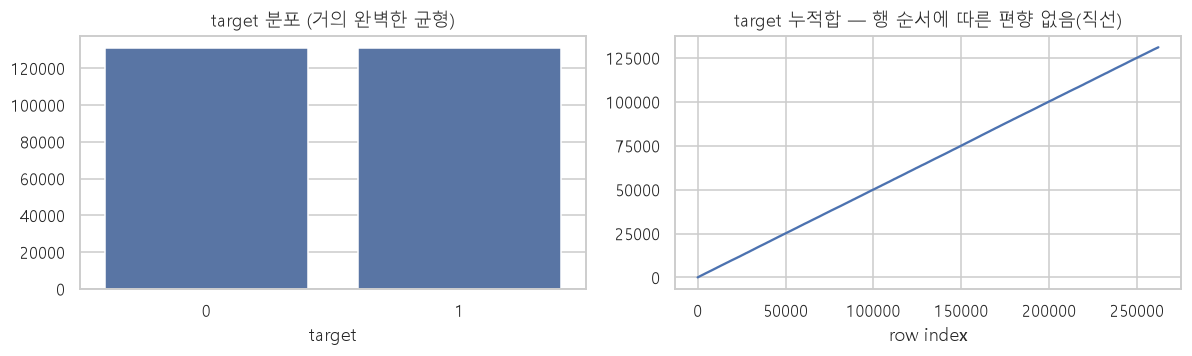

In [4]:
target_counts = train_df["target"].value_counts().sort_index()
print(target_counts.to_string())
print(f"positive ratio: {train_df['target'].mean():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
sns.barplot(x=target_counts.index.astype(str), y=target_counts.to_numpy(), ax=axes[0])
axes[0].set_title("target 분포 (거의 완벽한 균형)")
axes[0].set_xlabel("target")

# 누적합: 잘 섞인 데이터면 기울기 0.5 의 직선이 된다
axes[1].plot(train_df["target"].cumsum().to_numpy())
axes[1].set_title("target 누적합 — 행 순서에 따른 편향 없음(직선)")
axes[1].set_xlabel("row index")
plt.tight_layout()
plt.show()

> **관찰.** 결측치 0개, 클래스 50:50, 누적합은 완벽한 직선이다.
>
> 실무적 함의:
> - 결측 처리 코드가 필요 없다
> - 정확도 대신 AUC 를 쓰는 것이 자연스럽고, 샘플링 조정도 필요 없다
> - **행 순서에 편향이 없으므로 단순 `StratifiedKFold` 로 CV 를 짜도 안전하다**
>
> 세 가지 모두 "문제 없음"이라 심심해 보이지만, 이걸 확인해 두었기 때문에
> 앞으로 이 문제들을 **다시 걱정하지 않아도 된다**. EDA 의 절반은 이런 안심 장치다.

## 2. `wheezy-copper-turtle-magic` — 유일하게 이산적인 컬럼

**무엇을 하나** — 컬럼마다 **서로 다른 값이 몇 개인지(nunique)** 세어 본다.

**왜 하나** — 이것이 **숨은 범주형(categorical) 컬럼을 찾는 표준 절차**다.
피처 이름이 전부 무작위 단어라 이름만 보고는 아무것도 알 수 없다.
그럴 때는 **값의 성질**로 컬럼의 정체를 추론해야 한다.

**원리** — 연속형 실수 컬럼은 262,144행이면 unique 값도 262,144개에 가깝다
(같은 실수가 우연히 두 번 나올 확률은 거의 0). 반대로 **범주형·정수형 컬럼은
unique 값이 훨씬 적다.** 그래서 nunique 를 오름차순 정렬하면 범주형이 맨 위로 올라온다.

**기대 결과** — 대부분 262,144 근처. 그 중 하나라도 눈에 띄게 작다면 그게 범주형이다.

> **초보자에게** — 이 한 줄이 이 대회의 승부처였다.
> 캐글에서 "magic feature 를 찾았다"는 표현은 대개 이런 식의 단순한 스캔에서 나온다.
> 복잡한 기법보다 **기본 점검을 빠짐없이 하는 것**이 먼저다.

In [5]:
# 컬럼별 고유값 개수를 세어 오름차순 정렬 -> 범주형 컬럼이 맨 위로 온다
nunique = train_df[feature_cols].nunique().sort_values()
print(nunique.head(5).to_string())
print("...")
print(nunique.tail(3).to_string())

wheezy-copper-turtle-magic            512
hasty-gold-flamingo-novice         262144
woolly-flax-moth-unsorted          262144
smelly-chocolate-dogfish-fimbus    262144
crabby-ochre-iguana-golden         262144
...
blurry-chocolate-ostrich-pembus    262144
silly-indigo-jackal-distraction    262144
squirrely-amber-rabbit-golden      262144


magic 값 개수: 512
그룹당 행 수 요약:
min     511.0
mean    512.0
max     513.0
test 에도 동일한 512개 그룹 존재: 512


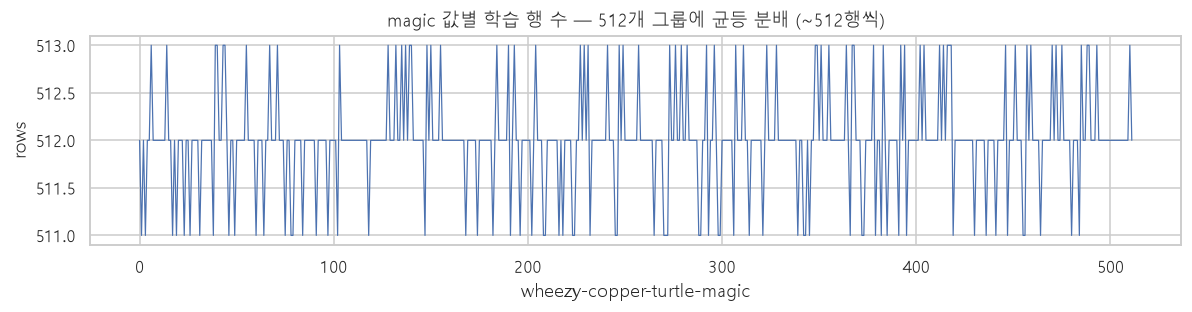

In [6]:
magic_counts = train_df[MAGIC_COL].value_counts().sort_index()
print("magic 값 개수:", train_df[MAGIC_COL].nunique())
print("그룹당 행 수 요약:")
print(magic_counts.describe()[["min", "mean", "max"]].to_string())
print("test 에도 동일한 512개 그룹 존재:", test_meta[MAGIC_COL].nunique())

plt.figure(figsize=(11, 3))
plt.plot(magic_counts.index, magic_counts.to_numpy(), lw=0.8)
plt.title("magic 값별 학습 행 수 — 512개 그룹에 균등 분배 (~512행씩)")
plt.xlabel(MAGIC_COL)
plt.ylabel("rows")
plt.tight_layout()
plt.show()

> **관찰 1 — 이 대회의 핵심.**
> 255개 컬럼은 unique 값이 262,144개인데 `wheezy-copper-turtle-magic` 만 **512개**다.
> 그리고 **262,144 = 512 × 512**. 즉 이 컬럼은 데이터를
> **한 그룹당 약 512행씩, 512개의 작은 데이터셋으로 쪼개는 열쇠**다.
> test 에도 똑같이 512개 그룹이 있다.
>
> **왜 이게 중요한가?** 각 그룹이 서로 다른 규칙으로 만들어졌다면,
> 512개 그룹을 뭉쳐서 하나의 모델을 학습시키는 순간 규칙들이 서로 상쇄되어 신호가 사라진다.
> 그래서 baseline 은 `for magic in range(512):` 루프를 돌며 **그룹마다 모델을 새로 학습**한다.
>
> 이 가설이 맞는지는 4절에서 검증한다.

## 3. 피처 분포 — 전체 데이터에서는 신호가 보이지 않는다

**무엇을 하나** — 피처들의 기술통계를 보고, target 별 분포를 겹쳐 그리고,
**단일 피처만으로 AUC 를 계산**해 본다.

**왜 하나** — "이 피처가 쓸모 있나?"를 재는 가장 싼 방법이기 때문이다.
모델을 학습시키기 전에 피처 하나하나의 예측력을 먼저 재 두면,
나중에 모델 성능이 이상할 때 **피처 탓인지 모델 탓인지** 구분할 수 있다.

**원리 — 단일 피처 AUC**
`roc_auc_score(y, x)` 에 피처 값 `x` 를 그대로 넣으면
"이 피처 값이 클수록 target=1 인 경향"이 얼마나 강한지가 나온다.
- 0.5 ≈ 무관
- 0.5보다 크게 벗어남 = 단조 관계 있음 (0.4 도 신호다. 방향이 반대일 뿐)

**기대 결과** — 만약 데이터가 그냥 평범했다면 몇몇 피처는 0.55~0.7 정도가 나와야 한다.

In [7]:
num_cols = [c for c in feature_cols if c != MAGIC_COL]
describe_train = train_df[num_cols].describe().T.drop("count", axis=1)

cmap = sns.diverging_palette(5, 250, as_cmap=True)
# 원본 노트북의 `Styler.set_precision` 은 최신 pandas 에서 제거됨 -> `.format` 사용
describe_train.head(10).style.background_gradient(cmap=cmap, axis=0).format("{:.2f}")

,mean,std,min,25%,50%,75%,max
hasty-gold-flamingo-novice,-0.00,1.81,-15.84,-0.79,0.00,0.78,14.99
smelly-chocolate-dogfish-fimbus,0.01,1.82,-20.41,-0.78,0.00,0.79,15.76
woolly-flax-moth-unsorted,0.01,1.73,-15.62,-0.77,0.00,0.78,16.88
homey-emerald-beagle-grandmaster,0.00,1.70,-15.56,-0.76,-0.00,0.76,15.73
crabby-ochre-iguana-golden,0.01,1.73,-15.73,-0.77,0.00,0.77,16.46
geeky-ochre-cuscus-pembus,-0.00,1.82,-15.87,-0.79,-0.00,0.79,15.47
messy-pink-kiwi-sorted,-0.01,1.67,-15.74,-0.76,-0.00,0.76,16.77
pokey-plum-tarantula-grandmaster,-0.00,1.72,-19.08,-0.77,0.00,0.77,17.57
snoopy-cream-wolfhound-expert,0.01,1.69,-19.75,-0.76,0.00,0.77,16.10
snoopy-olive-alligator-fepid,-0.01,1.74,-15.39,-0.78,0.00,0.77,15.58


In [8]:
# 255개 피처 각각의 통계량이 "피처들 사이에서" 어떻게 흩어져 있는지 요약
print("255개 피처의 기술통계 요약(피처들 사이의 분포):")
print(describe_train[["mean", "std", "min", "max"]].describe().loc[["min", "50%", "max"]].round(3).to_string())

255개 피처의 기술통계 요약(피처들 사이의 분포):
      mean    std     min     max
min -0.017  1.583 -21.334  13.752
50%  0.001  1.751 -16.301  16.275
max  0.021  1.919 -13.726  20.424


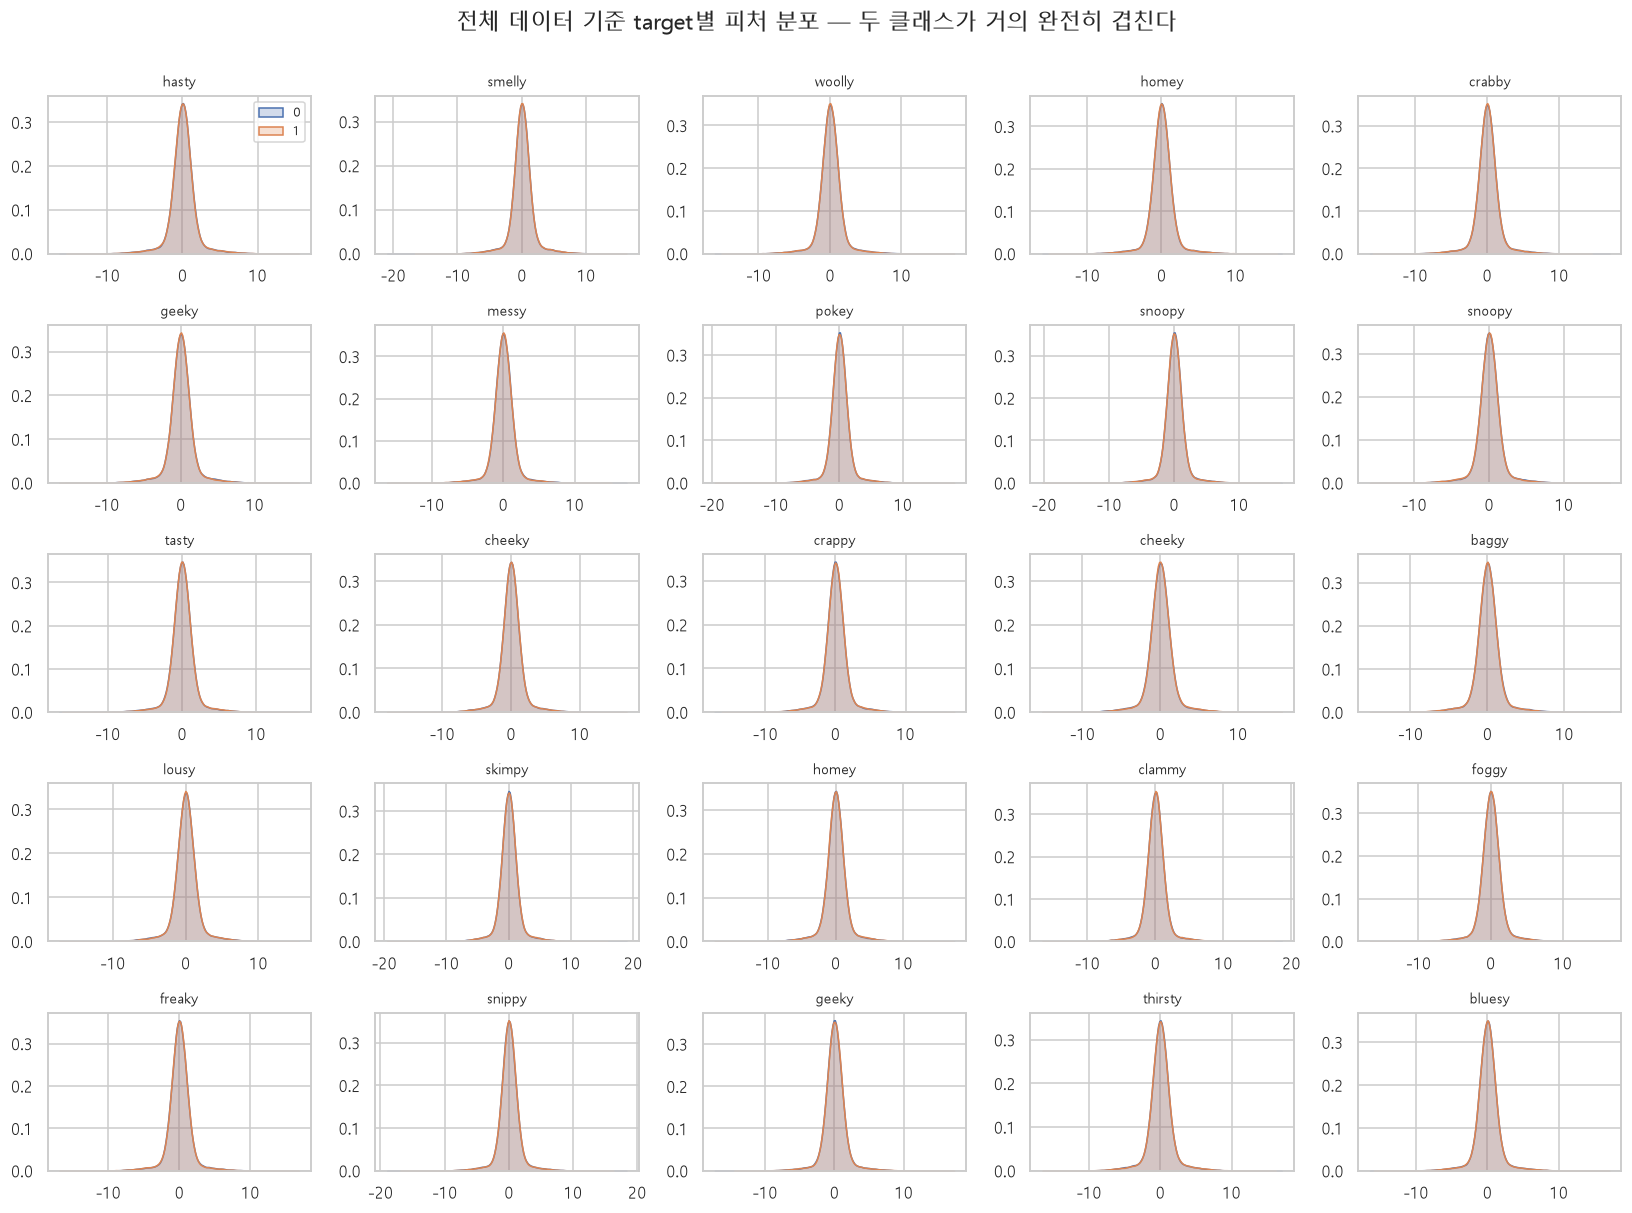

In [9]:
train_0 = train_df.loc[train_df["target"] == 0]
train_1 = train_df.loc[train_df["target"] == 1]

plt.figure(figsize=(15, 11))
for i, col in enumerate(num_cols[:25]):
    plt.subplot(5, 5, i + 1)
    # 원본의 sns.distplot 은 deprecated -> kdeplot 사용
    # kdeplot: 히스토그램을 매끄러운 곡선으로 추정해 그린 것 (분포 비교에 편하다)
    sns.kdeplot(train_0[col], label="0", fill=True, alpha=0.25, lw=1)
    sns.kdeplot(train_1[col], label="1", fill=True, alpha=0.25, lw=1)
    plt.title(col.split("-")[0], fontsize=9)   # 이름이 길어서 첫 단어만 표시
    plt.xlabel("")
    plt.ylabel("")
    if i == 0:
        plt.legend(fontsize=8)
plt.suptitle("전체 데이터 기준 target별 피처 분포 — 두 클래스가 거의 완전히 겹친다", y=1.001)
plt.tight_layout()
plt.show()

전체 데이터에서 보면 모든 피처가 0을 중심으로 대칭인 단봉 분포이고 target 0/1 분포가 거의 완전히 포개진다.
실제로 단일 피처 AUC를 재보면 0.5 근처다.

In [10]:
from sklearn.metrics import roc_auc_score

# 피처 값 자체를 예측 점수로 써서 AUC 를 계산 -> 단일 피처의 예측력
global_auc = pd.Series(
    {c: roc_auc_score(train_df["target"], train_df[c]) for c in num_cols[:40]}
)
print("전체 데이터 기준 단일 피처 AUC (앞 40개):")
print(global_auc.describe()[["min", "mean", "max"]].round(4).to_string())

전체 데이터 기준 단일 피처 AUC (앞 40개):
min     0.4955
mean    0.4996
max     0.5040


> **관찰 2.** 단일 피처 AUC 가 0.4955 ~ 0.5040 — **전부 동전 던지기 수준**이다.
>
> 여기서 초보자가 흔히 내리는 잘못된 결론이 두 가지 있다.
> - ❌ "데이터에 신호가 없다" → 그러면 이 대회에서 아무도 0.5 를 못 넘겼어야 한다
> - ❌ "더 센 모델을 쓰면 된다" → 입력에 신호가 없으면 어떤 모델도 만들어내지 못한다
>
> 올바른 결론은 세 번째다.
> **"내가 데이터를 보는 단위가 틀렸을 수 있다."**
> 2절에서 데이터가 512개 그룹으로 쪼개져 있다는 걸 알았으니,
> **그룹 안에서 다시 보면** 어떨지 확인해야 한다.

## 4. 핵심 인사이트 — 신호는 `magic` 그룹 안에 숨어 있다

**무엇을 하나** — 512개 그룹별로 각 피처의 **표준편차**를 계산한다.

**왜 하필 표준편차인가?**
`make_classification` 계열로 합성 데이터를 만들면,
**정보를 담은 피처는 클래스 중심들이 서로 떨어진 곳에 배치**되기 때문에
그 방향의 값이 넓게 퍼진다(= 표준편차가 크다).
반면 아무 정보 없는 잡음 피처는 표준정규분포 그대로라 **표준편차가 1 근처**다.
즉 **표준편차는 "이 피처가 이 그룹에서 쓰였는가"를 알려주는 지문**이다.

**기대 결과** — 값이 두 무리로 갈라지는 **이봉(bimodal) 분포**.
1 근처의 큰 봉우리(잡음)와 그보다 큰 값의 작은 봉우리(신호).
만약 하나의 봉우리만 나온다면 이 가설은 틀린 것이다.

group_std shape: (512, 255)


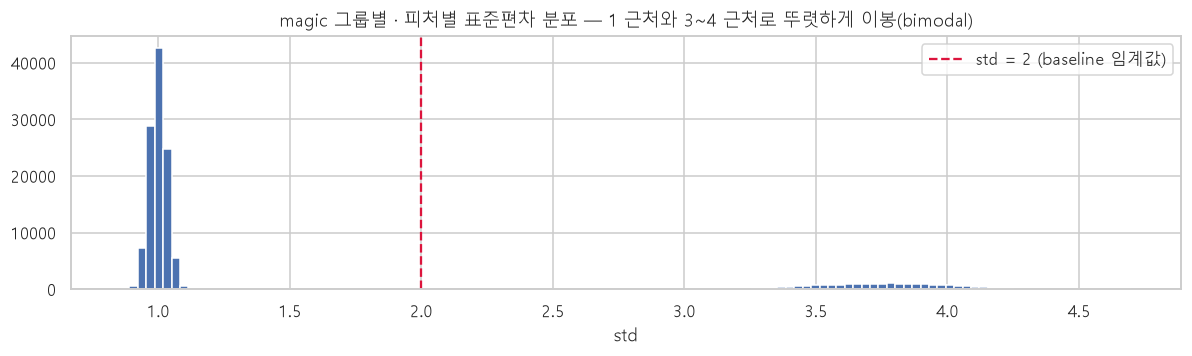


magic 그룹당 std > 2 인 피처 개수:
min     33.00
mean    39.68
max     47.00


In [11]:
# groupby(...).std() -> (512개 그룹) x (255개 피처) 표준편차 행렬
group_std = train_df.groupby(MAGIC_COL)[num_cols].std()
print("group_std shape:", group_std.shape)

plt.figure(figsize=(11, 3.4))
plt.hist(group_std.to_numpy().ravel(), bins=120)   # 512*255 = 130,560개 값을 전부 히스토그램
plt.axvline(2.0, color="crimson", ls="--", label="std = 2 (baseline 임계값)")
plt.title("magic 그룹별 · 피처별 표준편차 분포 — 1 근처와 3~4 근처로 뚜렷하게 이봉(bimodal)")
plt.xlabel("std")
plt.legend()
plt.tight_layout()
plt.show()

useful_per_magic = (group_std > 2).sum(axis=1)
print("\nmagic 그룹당 std > 2 인 피처 개수:")
print(useful_per_magic.describe()[["min", "mean", "max"]].round(2).to_string())

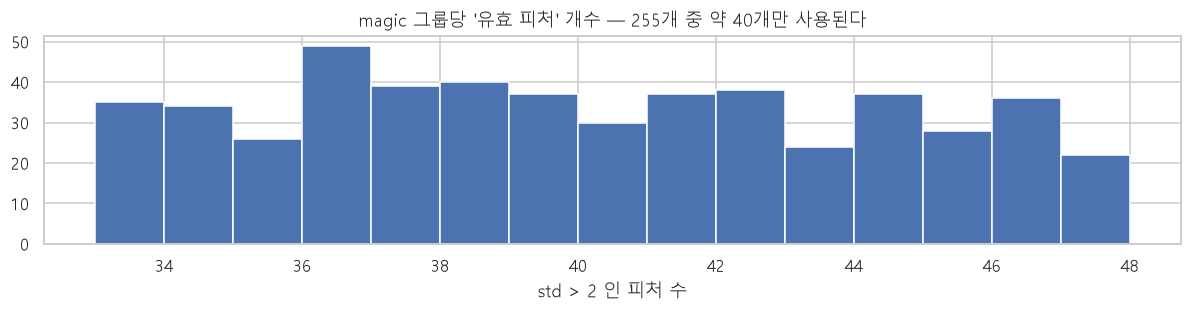

In [12]:
plt.figure(figsize=(11, 3))
plt.hist(useful_per_magic.to_numpy(), bins=range(int(useful_per_magic.min()), int(useful_per_magic.max()) + 2))
plt.title("magic 그룹당 '유효 피처' 개수 — 255개 중 약 40개만 사용된다")
plt.xlabel("std > 2 인 피처 수")
plt.tight_layout()
plt.show()

> **관찰 3 — 예측이 정확히 맞았다.**
> 표준편차가 **1 근처(잡음)와 3.4~4.1(신호)** 로 완전히 갈라진다.
> 두 무리 사이에 값이 거의 없어서, **어디서 잘라도 같은 결과**가 나온다.
> baseline 이 `std > 2` 를 쓰는 이유이며, 이 임계값이 얼마나 둔감한지는
> [03 노트북](03_feature_engineering.ipynb) 2절에서 실제로 스윕해 확인한다.
>
> 그룹당 유효 피처는 평균 **39.7개** (255개 중). 나머지 215개는 순수한 잡음이다.
>
> **여기서 배울 점:** baseline 의 `cols = train_std.index[train_std > 2]` 는 한 줄짜리 코드지만,
> 사실상 **그룹별 자동 피처 선택기**다. 좋은 피처 엔지니어링은 대개
> 이렇게 **데이터의 생성 구조를 이해한 결과로 나오는 단순한 규칙**이다.

In [13]:
# 그룹마다 선택되는 피처 집합이 실제로 다른지 확인한다.
# 만약 모든 그룹이 같은 40개를 쓴다면 굳이 그룹별로 나눌 이유가 없다.
sel_0 = set(group_std.columns[group_std.loc[0] > 2])
sel_1 = set(group_std.columns[group_std.loc[1] > 2])
sel_2 = set(group_std.columns[group_std.loc[2] > 2])
print(f"magic=0 유효 피처 {len(sel_0)}개, magic=1 {len(sel_1)}개, magic=2 {len(sel_2)}개")
print("magic 0 ∩ 1 :", len(sel_0 & sel_1))
print("magic 0 ∩ 2 :", len(sel_0 & sel_2))

# 반대 방향: 각 피처가 몇 개의 그룹에서 유효한지
times_useful = (group_std > 2).sum(axis=0)
print("\n피처 하나가 유효 피처로 뽑히는 그룹 수:")
print(times_useful.describe()[["min", "mean", "max"]].round(2).to_string())

magic=0 유효 피처 46개, magic=1 38개, magic=2 36개
magic 0 ∩ 1 : 7
magic 0 ∩ 2 : 4

피처 하나가 유효 피처로 뽑히는 그룹 수:
min      60.00
mean     79.66
max     102.00


> **관찰 4.** 그룹 0과 1이 공유하는 유효 피처는 46개 중 **7개뿐**이다.
> 즉 **그룹마다 쓰는 피처가 다르다.** 512개 그룹을 뭉쳐서 학습하면,
> 어떤 그룹에서는 신호인 피처가 다른 그룹에서는 잡음이라 서로 상쇄된다.
> 3절에서 단일 피처 AUC 가 0.5 였던 이유가 바로 이것이다.

## 5. 그룹 안에서 다시 보기 — 여기서부터 신호가 보인다

**무엇을 하나** — 그룹 하나(magic=0, 512행)를 골라 그 안에서만 단일 피처 AUC 를 다시 잰다.
그리고 **유효 피처와 잡음 피처를 나눠서** 비교한다.

**왜 나눠서 비교하나** — "유효 피처의 AUC 가 0.62 였다"는 말만으로는 부족하다.
512행에서 재는 AUC 는 그 자체로 흔들리기 때문에, **잡음 피처도 우연히 0.56 정도는 나온다.**
따라서 반드시 **비교 대상(baseline)** 이 필요하다. 여기서는 잡음 피처가 그 역할을 한다.

**원리 — 왜 평균 |AUC − 0.5| 를 보나?**
AUC 0.62 와 0.38 은 **방향만 반대일 뿐 신호의 세기는 같다.**
그래서 그냥 평균을 내면 서로 상쇄되어 0.5 가 나와 버린다.
0.5 로부터의 **거리**를 평균 내야 신호 세기를 잴 수 있다.

**기대 결과** — 유효 피처의 평균 |AUC−0.5| 가 잡음 피처보다 뚜렷하게 커야 한다.

In [14]:
MAGIC_SAMPLE = 0
sub = train_df[train_df[MAGIC_COL] == MAGIC_SAMPLE]
sub_cols = sorted(group_std.columns[group_std.loc[MAGIC_SAMPLE] > 2])
print(f"magic={MAGIC_SAMPLE}: {len(sub)}행, 유효 피처 {len(sub_cols)}개")

noise_cols = [c for c in num_cols if c not in set(sub_cols)]
sub_auc = pd.Series({c: roc_auc_score(sub["target"], sub[c]) for c in sub_cols})
noise_auc = pd.Series({c: roc_auc_score(sub["target"], sub[c]) for c in noise_cols})

# |AUC - 0.5| 로 신호의 '세기'를 잰다 (방향은 무시)
comparison = pd.DataFrame(
    {
        "유효 피처(std>2)": [len(sub_auc), sub_auc.min(), sub_auc.max(), (sub_auc - 0.5).abs().mean()],
        "노이즈 피처(std<=2)": [len(noise_auc), noise_auc.min(), noise_auc.max(), (noise_auc - 0.5).abs().mean()],
    },
    index=["개수", "AUC min", "AUC max", "평균 |AUC - 0.5|"],
).round(4)
print(f"\nmagic={MAGIC_SAMPLE} 그룹 내부 단일 피처 AUC 비교")
print(comparison.to_string())

magic=0: 512행, 유효 피처 46개



magic=0 그룹 내부 단일 피처 AUC 비교
                유효 피처(std>2)  노이즈 피처(std<=2)
개수                   46.0000        209.0000
AUC min               0.3620          0.4441
AUC max               0.6178          0.5662
평균 |AUC - 0.5|        0.0471          0.0199


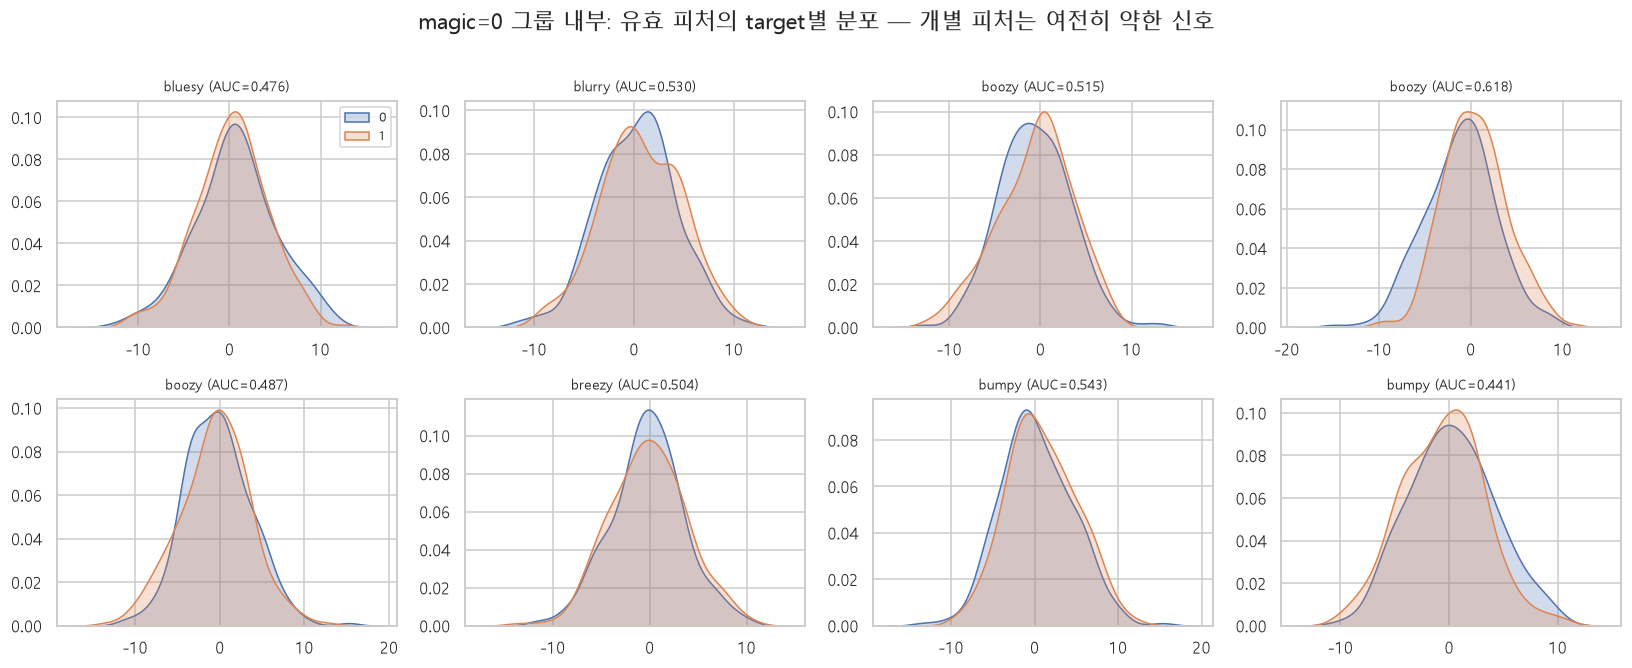

In [15]:
fig, axes = plt.subplots(2, 4, figsize=(15, 6))
for ax, col in zip(axes.ravel(), sub_cols[:8]):
    sns.kdeplot(sub.loc[sub["target"] == 0, col], label="0", fill=True, alpha=0.25, lw=1, ax=ax)
    sns.kdeplot(sub.loc[sub["target"] == 1, col], label="1", fill=True, alpha=0.25, lw=1, ax=ax)
    ax.set_title(f"{col.split('-')[0]} (AUC={sub_auc[col]:.3f})", fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("")
axes[0, 0].legend(fontsize=8)
plt.suptitle(f"magic={MAGIC_SAMPLE} 그룹 내부: 유효 피처의 target별 분포 — 개별 피처는 여전히 약한 신호", y=1.01)
plt.tight_layout()
plt.show()

**무엇을 하나** — 이번엔 클래스별로 **평균**과 **표준편차**를 따로 계산해 비교한다.

**왜 하나** — 두 클래스를 가르는 것이 **위치(평균)** 인지 **퍼짐(분산)** 인지에 따라
**써야 할 모델이 달라지기 때문**이다.

| 클래스 차이가 어디에 있나 | 적합한 모델 |
|---|---|
| 평균 위치가 다르다 | 로지스틱 회귀, LDA — 직선 하나로 가른다 |
| 분산·공분산 구조가 다르다 | **QDA**, 커널 SVM — 곡면으로 가른다 |
| 클래스가 여러 덩어리로 나뉜다 | **GMM**, KNN — 국소 구조를 본다 |

**원리 — QDA 와 LDA 의 차이**
둘 다 "각 클래스가 가우시안 분포를 따른다"고 가정한다. 차이는 공분산이다.
- **LDA**: 두 클래스의 공분산이 **같다**고 가정 → 경계가 **직선(초평면)**
- **QDA**: 클래스마다 공분산을 **따로 추정** → 경계가 **곡면(이차곡면)**

따라서 평균은 같은데 퍼짐이 다르면 LDA·로지스틱 회귀는 원리적으로 못 가르고, QDA 는 가른다.

**기대 결과** — 평균 차이가 작고 표준편차 비가 1에서 흩어져 있다면 QDA 계열이 유리하다.

In [16]:
cmp = pd.DataFrame(
    {
        "std_target0": sub.loc[sub["target"] == 0, sub_cols].std(),
        "std_target1": sub.loc[sub["target"] == 1, sub_cols].std(),
        "mean_target0": sub.loc[sub["target"] == 0, sub_cols].mean(),
        "mean_target1": sub.loc[sub["target"] == 1, sub_cols].mean(),
    }
)
cmp["std_ratio"] = cmp["std_target1"] / cmp["std_target0"]     # 1에서 멀수록 분산 구조가 다름
cmp["mean_diff"] = (cmp["mean_target1"] - cmp["mean_target0"]).abs()
print("클래스별 평균 차이 vs 표준편차 비율:")
print(cmp[["mean_diff", "std_ratio"]].describe().loc[["mean", "min", "max"]].round(3).to_string())
cmp.head(8).round(3)

클래스별 평균 차이 vs 표준편차 비율:
      mean_diff  std_ratio
mean      0.663      0.991
min       0.015      0.817
max       2.006      1.204


,std_target0,std_target1,mean_target0,mean_target1,std_ratio,mean_diff
bluesy-mustard-dragonfly-kernel,4.473,3.997,0.650,0.276,0.894,0.374
blurry-burgundy-blue-fimbus,3.913,4.058,0.273,0.701,1.037,0.428
boozy-khaki-whippet-discard,3.899,4.147,-0.628,-0.613,1.064,0.015
boozy-malachite-beetle-discard,3.875,3.457,-1.187,0.453,0.892,1.640
boozy-persimmon-iguana-expert,3.915,4.176,-0.239,-0.584,1.067,0.345
breezy-azure-pinscher-distraction,3.727,3.954,-0.241,-0.156,1.061,0.085
bumpy-chartreuse-blue-gaussian,4.271,4.162,0.244,0.871,0.974,0.627
bumpy-emerald-cat-dummy,3.941,3.764,0.278,-0.597,0.955,0.875


> **관찰 5.** 그룹 안에서 유효 피처는 잡음 피처보다 신호가 **2.4배 강하다**
> (평균 |AUC−0.5| 0.047 vs 0.020). 3절에서 0.5 였던 것과 대조된다 — **보는 단위를 바꾸니 신호가 나타났다.**
>
> 다만 **어느 피처도 단독으로는 약하다**. 클래스 평균 차이는 피처 표준편차의 0.2배 수준이고,
> 클래스별 표준편차 비는 0.82~1.20 으로 흩어져 있다.
> 즉 클래스를 가르는 것은 평균 위치보다 **분산 구조와 군집 형태**에 가깝다.
>
> 이 데이터는 `make_classification` 계열로 생성되어 클래스마다 여러 개의 가우시안 군집이
> 섞여 있는 구조인데, 그래서 클래스별 공분산을 따로 추정하는 **QDA**,
> 비선형 커널 **NuSVC/SVC**, 혼합 가우시안을 적합해 소속 확률을 뽑는 **GMM 파생 피처**가 잘 통한다.
> 반대로 단일 초평면만 긋는 LogisticRegression 은 그룹 안에서 6개 모델 중 가장 낮은 점수를 낸다.
>
> (단, LogisticRegression 에는 **반전이 하나** 있다. [04 노트북](04_model_diagnostics.ipynb) 3절을 보라.)

## 6. 상관구조 — 차원 축소를 해도 될까?

**무엇을 하나** — 유효 피처들 사이의 상관계수를 본다.

**왜 하나** — **PCA 같은 차원 축소를 써도 되는지 판단**하기 위해서다.
PCA 는 "피처들이 서로 상관되어 있어서 실제 정보 차원은 더 적다"는 가정 위에서 작동한다.
피처들이 서로 무상관이면 **줄일 여분이 없고, 줄이면 그냥 정보가 사라진다.**

**원리** — 상관계수가 0 근처에 몰려 있다 = 각 피처가 **독립적인 정보**를 담고 있다
= 40차원이 정말로 40차원어치의 정보다.

**기대 결과** — 합성 데이터의 informative 피처는 보통 서로 독립이므로 상관이 0 근처일 것.
그렇다면 **차원을 줄이면 손해**라는 결론이 나온다 (이 예측은 [03](03_feature_engineering.ipynb) 3절에서 AUC 로 검증된다).

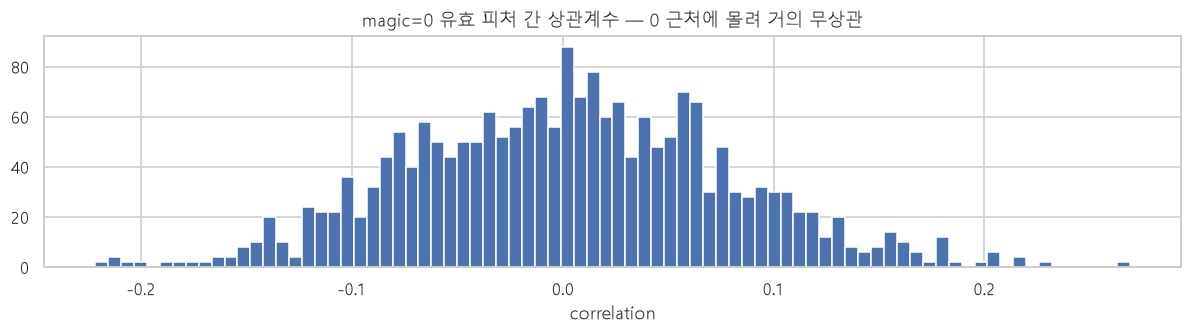

|corr| 평균: 0.0601,  최대: 0.2689


In [17]:
corr = sub[sub_cols].corr()
mask = np.eye(len(sub_cols), dtype=bool)     # 대각선(자기 자신과의 상관=1)은 제외
off_diag = corr.to_numpy()[~mask]

plt.figure(figsize=(11, 3.2))
plt.hist(off_diag, bins=80)
plt.title(f"magic={MAGIC_SAMPLE} 유효 피처 간 상관계수 — 0 근처에 몰려 거의 무상관")
plt.xlabel("correlation")
plt.tight_layout()
plt.show()

print(f"|corr| 평균: {np.abs(off_diag).mean():.4f},  최대: {np.abs(off_diag).max():.4f}")

> **관찰 6.** |상관| 평균 0.06 — 거의 무상관이다.
>
> 참고로 512행에서 상관계수를 재면 **참값이 0이어도** 표준오차가 1/√512 ≈ 0.044 이므로
> 0.06 은 사실상 "0과 구분되지 않는다"는 뜻이다. (이렇게 **관측값을 잡음 크기와 비교하는 습관**이
> EDA 에서 매우 중요하다. [02 노트북](02_magic_group_structure.ipynb) 3절에서 본격적으로 다룬다.)
>
> 그래서 baseline 은 차원을 **줄이지 않고**
> `KernelPCA(kernel="cosine", n_components=len(cols))` 로 **좌표계만 회전**시킨 뒤
> GMM·히스토그램 파생 피처를 덧붙인다.

## 7. 요약 — EDA 관찰이 baseline 설계로 이어지는 경로

| EDA 관찰 | baseline 반영 | 검증 위치 |
|---|---|---|
| 결측 없음, 타깃 50:50, 행 순서 편향 없음 | 별도 전처리 불필요, 단순 StratifiedKFold | — |
| `wheezy-copper-turtle-magic` 이 512개 하위 데이터셋을 구분 | magic 값별로 모델을 **따로** 학습 (512회 루프) | [02](02_magic_group_structure.ipynb) 2절 |
| 그룹마다 std > 2 인 피처 약 40개만 신호 | `train_std > 2` 로 그룹별 피처 선택 | [03](03_feature_engineering.ipynb) 2절 |
| 클래스 간 평균은 비슷하고 분산 구조가 다름 | QDA · NuSVC · SVC 중심 + GMM 파생 피처 | [03](03_feature_engineering.ipynb) 4절 |
| 유효 피처 간 상관 거의 없음 | KernelPCA 로 차원 유지, 축소하지 않음 | [03](03_feature_engineering.ipynb) 3절 |
| 그룹당 512행뿐이라 분산이 큼 | seed × GMM 초기화 4조합 평균 + 스태킹 | [04](04_model_diagnostics.ipynb) |

### 이 노트북에서 배운 EDA 원칙 4가지

1. **기본 점검을 빠짐없이 한다** — 결측·균형·순서. 문제가 없다는 확인도 수확이다
2. **이름이 아니라 값의 성질로 컬럼을 판단한다** — nunique 스캔이 magic 컬럼을 찾아냈다
3. **신호가 안 보이면 모델을 의심하기 전에 "보는 단위"를 의심한다** — 전체에서 0.5 였던 것이 그룹 안에서는 신호였다
4. **항상 비교 대상을 둔다** — 유효 피처의 AUC 는 잡음 피처와 비교했을 때만 의미가 있다

### 직접 해보기

- `MAGIC_SAMPLE` 을 0이 아닌 다른 값(예: 100, 511)으로 바꿔 보라. 결론이 유지되는가?
- 5절의 비교를 **잡음 피처만으로** 해 보라. 잡음끼리도 AUC 0.56 이 나오는 것을 확인하면,
  왜 비교 대상 없이 단일 숫자를 믿으면 안 되는지 체감할 수 있다
- `std > 2` 대신 `std > 1.2` 로 유효 피처를 뽑으면 몇 개가 선택되는가? 4절의 히스토그램으로 예측해 보고 확인해 보라

### 다음 노트북

[02_magic_group_structure](02_magic_group_structure.ipynb) 에서는
"그러면 이 512개 데이터셋은 대체 **어떻게 만들어진 것인가**"를 역으로 추적한다.